# Projeto 1 - Airbnb: características do imóvel e valor da diária

**Autores:**
- Anna Albuquerque
- Mateus Cortez Camacho

---

<center>
    <img src="airbnb.png">
</center>

A **definição do preço** de uma hospedagem é relevante tanto para anfitriões, que precisam estabelecer valores competitivos, quanto para hóspedes, que procuram entender o que justifica diferenças de preço. Este trabalho investiga quais características dos imóveis apresentam maior relação com o preço anunciado e se essa relação muda conforme a localização.

---

- **id**: Unique identifier for each listing - *Identificação*
- **name**: Name of the Airbnb listing - *Qualitativa Nominal*
- **rating**: Average rating of the listing - *Quantitativa Contínua*
- **reviews**: Number of reviews received - *Quantitativa Discreta*
- **host_name**: Name of the host - *Qualitativa Nominal*
- **host_id**: Unique identifier for the host - *Identificação*
- **address**: Location of the listing (city, region, country) - *Qualitativa Nominal*
- **features**: Summary of features (number of guests, bedrooms, beds, bathrooms) - *Qualitativa Nominal*
- **amenities**: List of amenities provided - *Qualitativa Nominal*
- **price**: Price per night in the local currency - *Quantitativa Discreta*
- **country**: Country where the listing is located - *Qualitativa Nominal*
- **bathrooms**: Number of bathrooms - *Quantitativa Discreta*
- **beds**: Number of beds - *Quantitativa Discreta*
- **guests**: Number of guests the listing can accommodate - *Quantitativa Discreta*
- **toiles**: Number of toilets - *Quantitativa Discreta*
- **bedrooms**: Number of bedrooms - *Quantitativa Discreta*
- **studios**: Number of studio units (0 = "Não", 1 = "Sim") - *Qualitativa Nominal Binária*
- **checkin**: Check-in time - *Qualitativa Nominal*
- **checkout**: Check-out time - *Qualitativa Nominal*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('airbnb.csv')
df.head()

,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,...,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...",...,8078,Turkey,1,1,2,0,2,0,Flexible,12 00 pm
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...",...,4665,Turkey,2,2,4,0,2,0,4 00 pm - 11 00 pm,10 00 am
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...",...,5991,Georgia,1,3,4,0,1,0,After 1 00 pm,12 00 pm
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...",...,11339,Turkey,1,2,4,0,1,0,After 2 00 pm,12 00 pm
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...",...,6673,Turkey,1,1,2,0,1,0,After 2 00 pm,12 00 pm


### Tamanho do DataFrame - 12805 linhas e 23 Colunas

In [3]:
df.shape

#12805 linhas e 23 Colunas

(12805, 23)

### Code de Variáveis - Apenas os de checkin(out) estão errados em string

In [4]:
df.dtypes

Unnamed: 0        int64
id                int64
name             object
rating           object
reviews          object
host_name        object
host_id         float64
address          object
features         object
amenities        object
safety_rules     object
hourse_rules     object
img_links        object
price             int64
country          object
bathrooms         int64
beds              int64
guests            int64
toiles            int64
bedrooms          int64
studios           int64
checkin          object
checkout         object
dtype: object

### Limpeza de Dados

In [5]:
#df = df.drop(columns=['Unnamed: 0']) #retirar a coluna "Unnamed", que é desnecessária#
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce') #converter ratings para numérico, pois era 
df['reviews_num'] = pd.to_numeric(df['reviews'], errors='coerce') #converter reviews para numérico

studios_sn = {0: "No", 1: "Yes"}
df["studios"] = df["studios"].replace(studios_sn) #trocar 0 e 1 por Não e Sim para melhor análise e visualização do gráfico

### Conversor de Moedas Estrangeiras para USD

In [6]:
import sys
print(sys.executable)
%pip install pycountry

c:\Users\al004\anaconda3\python.exe
Note: you may need to restart the kernel to use updated packages.


In [7]:
'''
import pandas as pd
import pycountry
import requests
from babel.numbers import get_territory_currencies
import datetime

# ==========================================================
# 1. Preparar a coluna de país
# ==========================================================
df['country'] = df['country'].str.strip() #alguns países possuem espaços no início.
paises = df['country'].unique()

# ==========================================================
# 2. Mapear país -> código da moeda (ISO 4217)
# ==========================================================
excecoes_manuais = {
    'Turkey': 'TRY',
    'Bosnia & Herzegovina': 'BAM',
    'Svalbard & Jan Mayen': 'NOK',
    'St Martin': 'EUR',
}

mapa_moeda = {}
for pais in paises:
    if pais in excecoes_manuais:
        mapa_moeda[pais] = excecoes_manuais[pais]
        continue
    try:
        c = pycountry.countries.search_fuzzy(pais)[0]
        moedas = get_territory_currencies(
            c.alpha_2,
            start_date=datetime.date(2024, 5, 28),
            end_date=datetime.date(2024, 5, 28)
        )
        mapa_moeda[pais] = moedas[0]
    except Exception:
        mapa_moeda[pais] = None

sem_moeda = [p for p, m in mapa_moeda.items() if m is None]
print("Países sem moeda mapeada:", sem_moeda)

# ==========================================================
# 3. Buscar as cotações históricas (data de publicação da base: 28/05/2024)
# ==========================================================
resp = requests.get("https://api.frankfurter.dev/v2/rates?base=usd&date=2024-05-28")
dados = resp.json()

cotacoes = {item['quote']: item['rate'] for item in dados}
cotacoes['USD'] = 1.0

print("Data de referência das cotações:", dados[0]['date'])

# ==========================================================
# 4. Aplicar a conversão
# ==========================================================
df['moeda'] = df['country'].map(mapa_moeda)
df['cotacao'] = df['moeda'].map(cotacoes)
df['price_usd'] = df['price'] / df['cotacao']

# ==========================================================
# 5. Validação: conferir se alguma linha ficou sem conversão
# ==========================================================
sem_conversao = df[df['price_usd'].isna()]['country'].unique()
print("Países sem cotação encontrada na API:", sem_conversao)
'''

import pandas as pd
import requests
import datetime

# ==========================================================
# 1. Preparar a coluna de país (mantido, útil pro resto da análise)
# ==========================================================
df['country'] = df['country'].str.strip()

# ==========================================================
# 2. Buscar a cotação histórica de referência (INR, data de publicação: 28/05/2024)
# ==========================================================
resp = requests.get("https://api.frankfurter.dev/v2/rates?base=usd&date=2024-05-28")
dados = resp.json()

cotacoes = {item['quote']: item['rate'] for item in dados}
taxa_referencia = cotacoes['INR']

print("Data de referência da cotação:", dados[0]['date'])
print("Taxa usada (INR por USD):", taxa_referencia)

# ==========================================================
# 3. Aplicar a conversão de escala única (mesma taxa pra toda a base)
# ==========================================================
df['price_usd'] = df['price'] / taxa_referencia

# ==========================================================
# 4. Conferência rápida
# ==========================================================
print(df['price_usd'].describe())

Data de referência da cotação: 2024-05-28
Taxa usada (INR por USD): 83.16
count    12805.000000
mean       212.816262
std        549.466609
min          4.725830
25%         48.027898
50%         98.304473
75%        193.145743
max      22943.278018
Name: price_usd, dtype: float64


### Escala Logarítimica pro USD

In [8]:
df['log_price_usd'] = np.log1p(df['price_usd'])  # log(1 + x), evita erro se houver 0

### Separar os Países por Continentes

In [9]:
mapa_continente = {
    # África
    'Congo': 'África', 'Egypt': 'África', 'Kenya': 'África', 'Madagascar': 'África',
    'Morocco': 'África', 'Namibia': 'África', 'Nigeria': 'África', 'Rwanda': 'África',
    'Senegal': 'África', 'Seychelles': 'África', 'South Africa': 'África',
    'Tanzania': 'África', 'Tunisia': 'África', 'Uganda': 'África', 'Mauritius': 'África',

    # Ásia
    'Armenia': 'Ásia', 'Azerbaijan': 'Ásia', 'Bangladesh': 'Ásia', 'Brunei': 'Ásia',
    'Cambodia': 'Ásia', 'Georgia': 'Ásia', 'Hong Kong': 'Ásia', 'India': 'Ásia',
    'Indonesia': 'Ásia', 'Israel': 'Ásia', 'Japan': 'Ásia', 'Jordan': 'Ásia',
    'Kazakhstan': 'Ásia', 'Kuwait': 'Ásia', 'Kyrgyzstan': 'Ásia', 'Lebanon': 'Ásia',
    'Malaysia': 'Ásia', 'Maldives': 'Ásia', 'Mongolia': 'Ásia', 'Myanmar': 'Ásia',
    'Nepal': 'Ásia', 'Oman': 'Ásia', 'Pakistan': 'Ásia', 'Philippines': 'Ásia',
    'Qatar': 'Ásia', 'Saudi Arabia': 'Ásia', 'Singapore': 'Ásia', 'South Korea': 'Ásia',
    'Sri Lanka': 'Ásia', 'Taiwan': 'Ásia', 'Thailand': 'Ásia', 'Turkey': 'Ásia',
    'United Arab Emirates': 'Ásia', 'Uzbekistan': 'Ásia', 'Vietnam': 'Ásia',

    # Europa
    'Albania': 'Europa', 'Austria': 'Europa', 'Belgium': 'Europa',
    'Bosnia & Herzegovina': 'Europa', 'Bulgaria': 'Europa', 'Croatia': 'Europa',
    'Cyprus': 'Europa', 'Czechia': 'Europa', 'Denmark': 'Europa', 'Estonia': 'Europa',
    'Finland': 'Europa', 'France': 'Europa', 'Germany': 'Europa', 'Greece': 'Europa',
    'Hungary': 'Europa', 'Iceland': 'Europa', 'Ireland': 'Europa', 'Isle of Man': 'Europa',
    'Italy': 'Europa', 'Kosovo': 'Europa', 'Latvia': 'Europa', 'Liechtenstein': 'Europa',
    'Lithuania': 'Europa', 'Malta': 'Europa', 'Montenegro': 'Europa', 'Netherlands': 'Europa',
    'Norway': 'Europa', 'Poland': 'Europa', 'Portugal': 'Europa', 'Romania': 'Europa',
    'Serbia': 'Europa', 'Slovakia': 'Europa', 'Slovenia': 'Europa', 'Spain': 'Europa',
    'Svalbard & Jan Mayen': 'Europa', 'Sweden': 'Europa', 'Switzerland': 'Europa',
    'Ukraine': 'Europa', 'United Kingdom': 'Europa', 'Åland Islands': 'Europa',

    # América do Norte (incluindo América Central e Caribe)
    'Bahamas': 'América do Norte', 'Belize': 'América do Norte', 'Canada': 'América do Norte',
    'Cayman Islands': 'América do Norte', 'Costa Rica': 'América do Norte', 'Cuba': 'América do Norte',
    'Greenland': 'América do Norte', 'Guadeloupe': 'América do Norte', 'Guatemala': 'América do Norte',
    'Honduras': 'América do Norte', 'Jamaica': 'América do Norte', 'Mexico': 'América do Norte',
    'Nicaragua': 'América do Norte', 'Panama': 'América do Norte', 'Puerto Rico': 'América do Norte',
    'St Martin': 'América do Norte', 'United States': 'América do Norte',

    # América do Sul
    'Argentina': 'América do Sul', 'Bolivia': 'América do Sul', 'Brazil': 'América do Sul',
    'Chile': 'América do Sul', 'Colombia': 'América do Sul', 'Peru': 'América do Sul',
    'Uruguay': 'América do Sul',

    # Oceania
    'Australia': 'Oceania', 'Fiji': 'Oceania', 'French Polynesia': 'Oceania',
    'New Zealand': 'Oceania', 'Vanuatu': 'Oceania',
}

df['country'] = df['country'].str.strip()
df['continente'] = df['country'].map(mapa_continente)

# checar se algum país ficou sem mapeamento
sem_match = df[df['continente'].isna()]['country'].unique()
print("Países sem continente mapeado:", sem_match)

Países sem continente mapeado: []


### Medidas Estatísticas USD por Continente

In [10]:
df.groupby('continente')['price_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
continente,,,,,,,,
América do Norte,562.0,274.469530,719.292342,9.511785,25.901876,87.632275,252.861953,11520.899471
América do Sul,49.0,389.121781,895.031577,12.313612,49.302549,120.141895,241.462241,5473.244348
Europa,4857.0,272.198459,617.978111,9.620010,86.435786,131.156806,239.682540,14689.454064
Oceania,41.0,289.456704,290.007942,37.421837,157.347282,223.965849,336.808562,1855.026455
África,584.0,149.629572,491.827297,9.836460,36.050986,67.400192,144.243025,10967.424242
Ásia,6712.0,168.425816,473.013869,4.725830,34.307359,68.626744,153.923160,22943.278018


### Medidas Estatísticas ln(USD) por Continente

In [11]:
analise_continente = df.groupby('continente')['log_price_usd'].agg(
    quantidade='count', mediana='median', media='mean'
).round(2).sort_values('mediana', ascending=False)

ordem = analise_continente.index

### Boxplot USD por continente

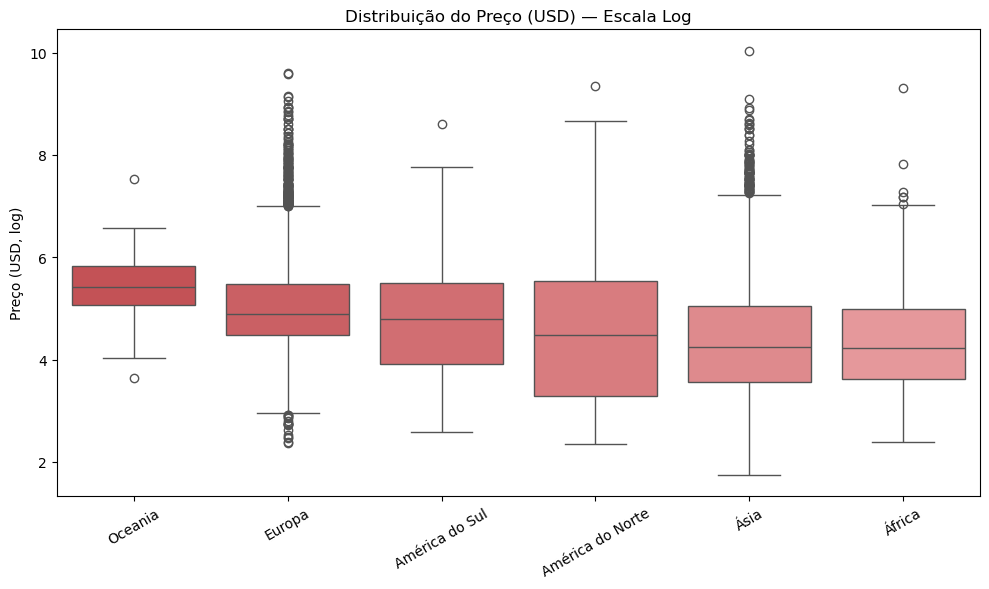

In [12]:
# Gradiente controlado: vermelho escuro → coral médio
cores = sns.blend_palette(
    ["#D63F45", "#F28B8F"],
    n_colors=len(ordem)
)

paleta = dict(zip(ordem, cores))

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="continente",
    y="log_price_usd",
    data=df,
    order=ordem,
    hue="continente",
    hue_order=ordem,
    palette=paleta,
    legend=False
)

plt.title("Distribuição do Preço (USD) — Escala Log")
plt.ylabel("Preço (USD, log)")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Gráfico de Barras Preços Medianos ln(USD) por Continente

## Usar só logarítmo

### Histogramas pra análise de log(USD) por continente -- Frequência Absoluta

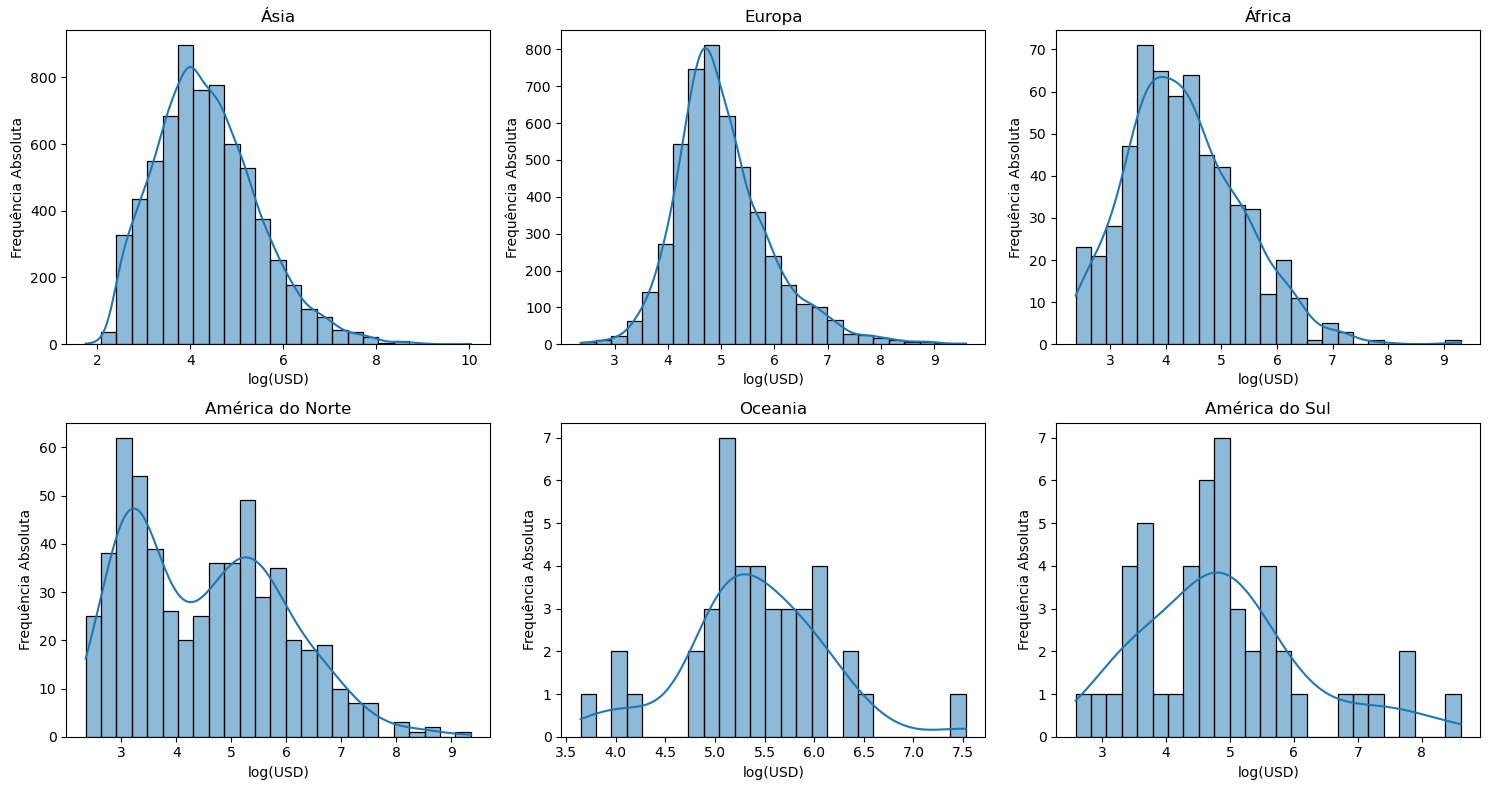

In [13]:
continentes = df['continente'].unique()
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
axes = axes.flatten()

for i, cont in enumerate(continentes):
    dados = df[df['continente'] == cont]['log_price_usd']
    sns.histplot(dados, bins=25, kde=True, ax=axes[i])
    axes[i].set_title(cont)
    axes[i].set_xlabel('log(USD)')
    axes[i].set_ylabel('Frequência Absoluta')

# remove eixos vazios se sobrar algum (caso continentes < 6)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Contagem de NaNs

In [14]:

# conta os NaNs por coluna e calcula o percentual
nulos = df.isna().sum()
percentual = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'qtd_nulos': nulos,
    'percentual (%)': percentual
}).sort_values('qtd_nulos', ascending=False)

print(resumo_nulos)

#Muitos Valores não preenchidos em Checkout e Checkin

               qtd_nulos  percentual (%)
rating_num          4238           33.10
checkout            2450           19.13
checkin              800            6.25
host_name              8            0.06
reviews_num            1            0.01
Unnamed: 0             0            0.00
bathrooms              0            0.00
log_price_usd          0            0.00
price_usd              0            0.00
studios                0            0.00
bedrooms               0            0.00
toiles                 0            0.00
guests                 0            0.00
beds                   0            0.00
country                0            0.00
id                     0            0.00
price                  0            0.00
img_links              0            0.00
hourse_rules           0            0.00
safety_rules           0            0.00
amenities              0            0.00
features               0            0.00
address                0            0.00
host_id         

### Contagem de Valores

In [15]:
colunas_categoricas = ['country', 'bathrooms', 'bedrooms', 'beds', 'guests', 'studios']

for col in colunas_categoricas:
    print(f"\n{'='*40}")
    print(f"Variável: {col}")
    print('='*40)
    print(df[col].value_counts().head(8))


#Depois dar uma verificada se tem nomes de países escritos de maneira alternativa e centralizar tudo


Variável: country
country
India       2779
Italy       1187
Greece       889
Thailand     683
Turkey       522
France       466
Morocco      377
Georgia      371
Name: count, dtype: int64

Variável: bathrooms
bathrooms
1    8000
2    1917
3     902
4     590
0     446
5     306
6     215
8     121
Name: count, dtype: int64

Variável: bedrooms
bedrooms
1    6374
2    2377
3    1406
4     772
0     692
5     420
6     251
7     135
Name: count, dtype: int64

Variável: beds
beds
1    3972
2    2981
3    1781
4    1283
5     701
6     517
0     277
8     270
Name: count, dtype: int64

Variável: guests
guests
2     3729
4     2607
6     1471
3     1228
8      732
5      702
16     640
10     457
Name: count, dtype: int64

Variável: studios
studios
No     12503
Yes      302
Name: count, dtype: int64


### Agrupamento dos Continentes por Mediana dos Países em USD

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# (usando o mapa_continente que já criamos)
df['continente'] = df['country'].map(mapa_continente)

# estatísticas por continente
analise_continente = df.groupby('continente')['price_usd'].agg(
    quantidade='count', mediana='median', media='mean'
).round(2).sort_values('mediana', ascending=False)

print(analise_continente)

# ordenar os continentes do mais caro pro mais barato (pela mediana)
ordem = analise_continente.index

                  quantidade  mediana   media
continente                                   
Oceania                   41   223.97  289.46
Europa                  4857   131.16  272.20
América do Sul            49   120.14  389.12
América do Norte         562    87.63  274.47
Ásia                    6712    68.63  168.43
África                   584    67.40  149.63


### Gráficos de Barra das Quantidades - Tudo OK

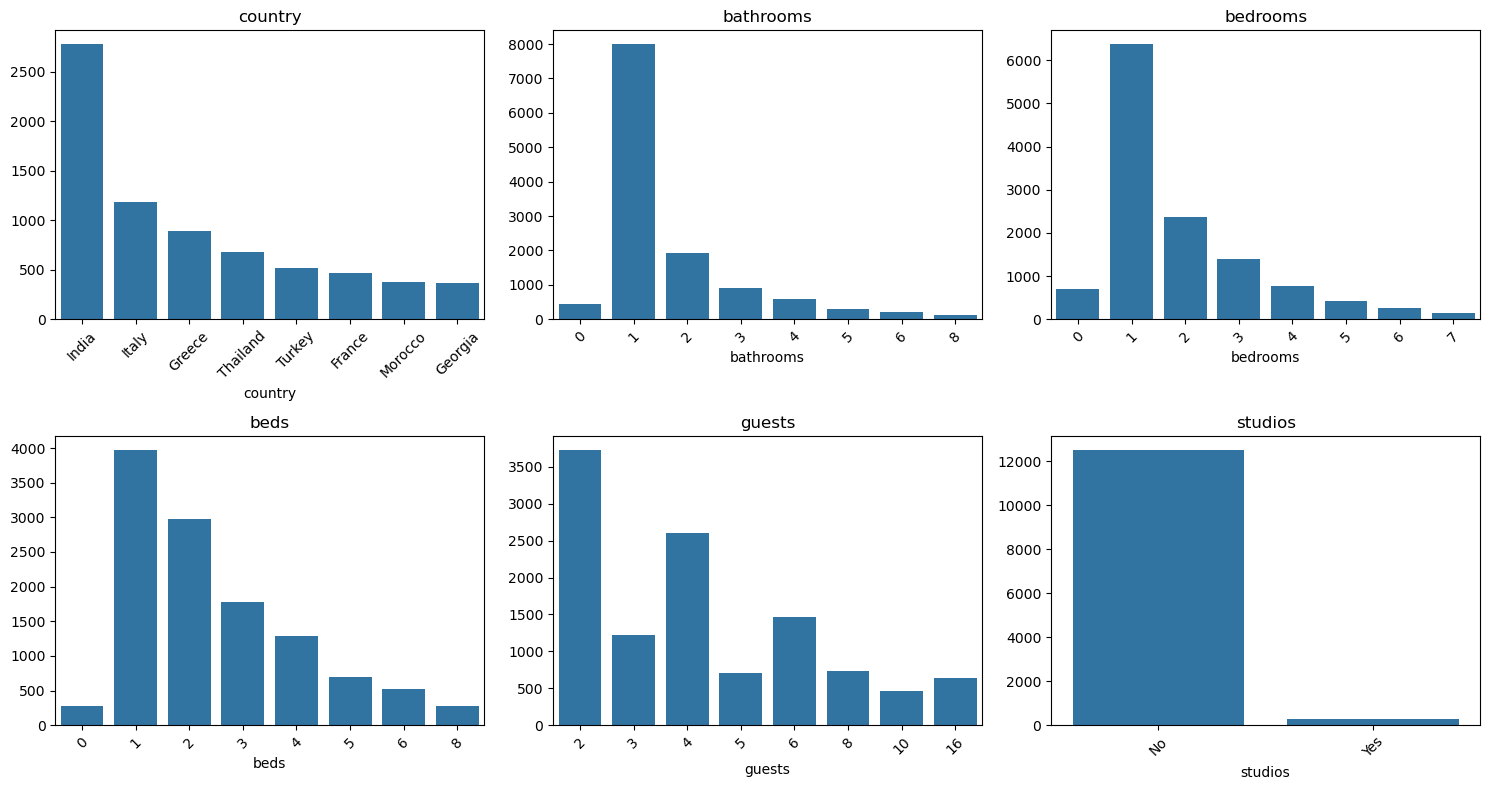

In [17]:
colunas_categoricas = ['country', 'bathrooms', 'bedrooms', 'beds', 'guests', 'studios']

n_cols = 3
n_rows = math.ceil(len(colunas_categoricas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    contagem = df[col].value_counts().head(8)
    sns.barplot(x=contagem.index, y=contagem.values, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# remove eixos vazios se sobrarem
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Duplicatas - Tudo Ok

In [18]:
df['id'].duplicated() 
print("Existem:",df['id'].duplicated().sum(),"valores duplicados na coluna id")

df['host_id'].duplicated() 
print("\nExistem:",df['host_id'].duplicated().sum(),"valores duplicados na coluna host_id")
df['host_name'].duplicated() 
print("Existem:",df['host_name'].duplicated().sum(),"valores duplicados na coluna host_name") #Justo ser diferente de host_id, pois eles podem ter apenas nomes iguais

Existem: 0 valores duplicados na coluna id

Existem: 2430 valores duplicados na coluna host_id
Existem: 5967 valores duplicados na coluna host_name


### Verificação de Outliers

In [19]:
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

for col in colunas_quant_disc:
    print(f"\n{'='*40}")
    print(f"Variável: {col}")
    print('='*40)
    print(df[col].describe())




Variável: bathrooms
count    12805.000000
mean         1.874424
std          2.091399
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         50.000000
Name: bathrooms, dtype: float64

Variável: bedrooms
count    12805.000000
mean         2.136041
std          2.359005
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         50.000000
Name: bedrooms, dtype: float64

Variável: beds
count    12805.000000
mean         3.316751
std          4.037791
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         98.000000
Name: beds, dtype: float64

Variável: guests
count    12805.000000
mean         5.213745
std          3.808830
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         16.000000
Name: guests, dtype: float64


### Boxplots pra verificação de outliers

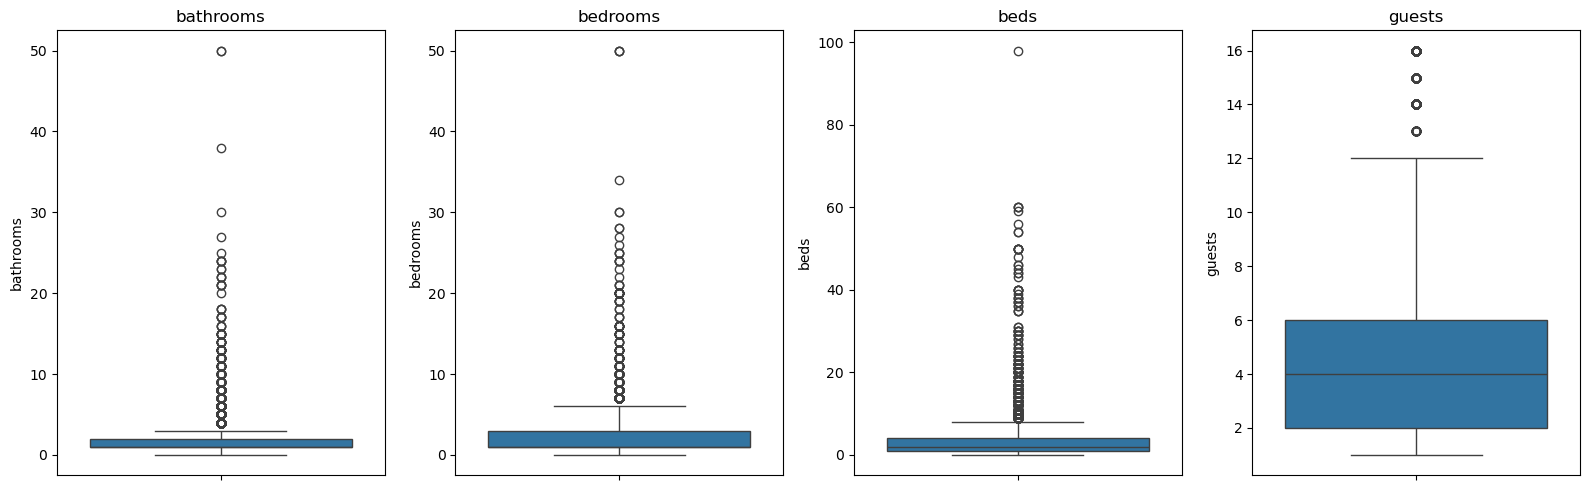

In [20]:
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

fig, axes = plt.subplots(1, len(colunas_quant_disc), figsize=(16, 5))

for i, col in enumerate(colunas_quant_disc):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#Guests faz sentido os outliers, mas o resto achp que dá pra remover

### Análise Interquartílica

In [21]:
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

for col in colunas_quant_disc:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    pct_outliers = n_outliers / len(df) * 100
    
    print(f"\n{'='*40}")
    print(f"Variável: {col}")
    print('='*40)
    print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
    print(f"Limite inferior: {lim_inf} | Limite superior: {lim_sup}")
    print(f"Outliers: {n_outliers} ({pct_outliers:.2f}%)")



Variável: bathrooms
Q1: 1.0 | Q3: 2.0 | IQR: 1.0
Limite inferior: -0.5 | Limite superior: 3.5
Outliers: 1540 (12.03%)

Variável: bedrooms
Q1: 1.0 | Q3: 3.0 | IQR: 2.0
Limite inferior: -2.0 | Limite superior: 6.0
Outliers: 513 (4.01%)

Variável: beds
Q1: 1.0 | Q3: 4.0 | IQR: 3.0
Limite inferior: -3.5 | Limite superior: 8.5
Outliers: 770 (6.01%)

Variável: guests
Q1: 2.0 | Q3: 6.0 | IQR: 4.0
Limite inferior: -4.0 | Limite superior: 12.0
Outliers: 921 (7.19%)


Todos tem bastante outliers, será que vale a pena tirar tudo?
Por enquanto, vou tirar só os que estão acima de 30

### Remoção dos Outliers Acima de 30

Linhas originais: 12805
Linhas removidas: 42
Linhas restantes: 12763


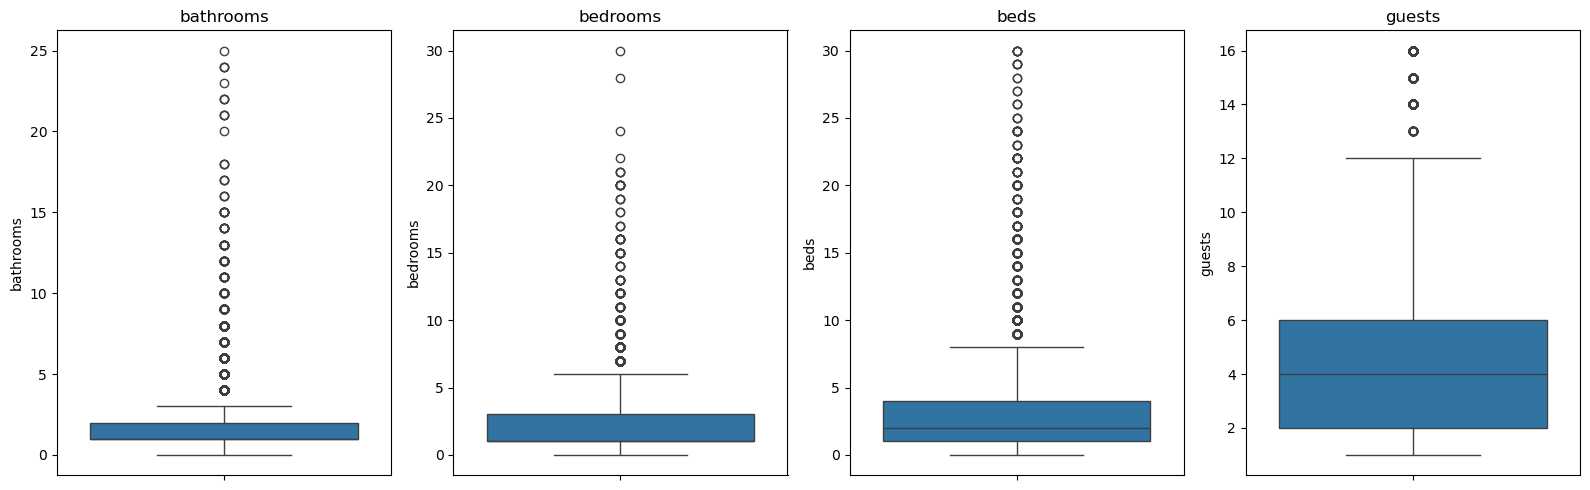

In [22]:
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

mask = pd.Series(True, index=df.index)
for col in colunas_quant_disc:
    mask &= (df[col] <= 30)

print(f"Linhas originais: {len(df)}")
print(f"Linhas removidas: {(~mask).sum()}")
print(f"Linhas restantes: {mask.sum()}")

df = df[mask].copy()

#Boxplot
colunas_quant_disc = ['bathrooms', 'bedrooms', 'beds', 'guests']

fig, axes = plt.subplots(1, len(colunas_quant_disc), figsize=(16, 5))

for i, col in enumerate(colunas_quant_disc):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Análise de Outliers dos Preços em Dólar

In [23]:
df['price_usd'].describe()

count    12763.000000
mean       211.621757
std        545.739203
min          4.725830
25%         48.027898
50%         98.328523
75%        192.863155
max      22943.278018
Name: price_usd, dtype: float64

### Histograma dos Preços em Log(USD) - Todos os países

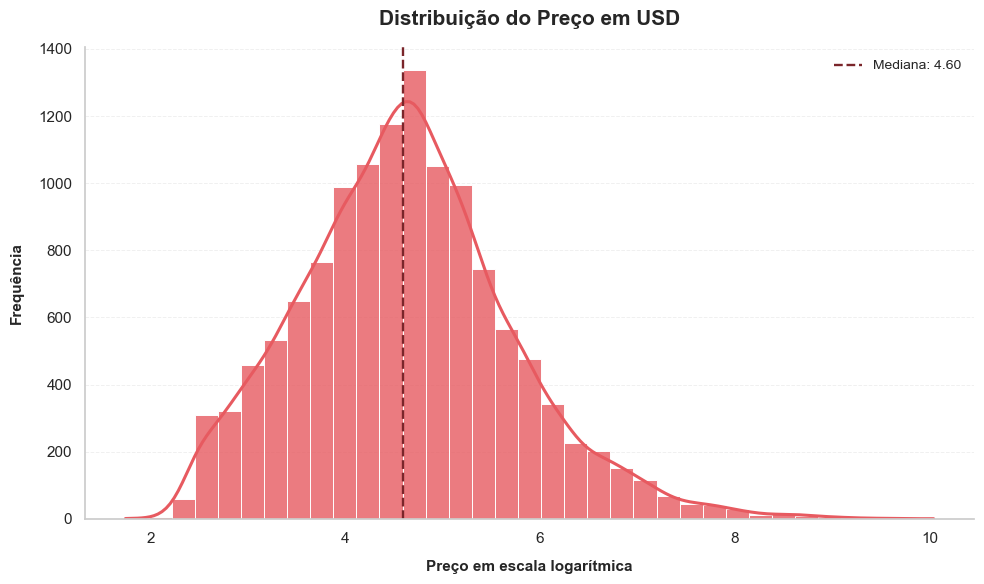

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="log_price_usd",
    bins=35,
    kde=True,
    color="#E75A60",
    edgecolor="white",
    linewidth=0.7,
    alpha=0.80,
    line_kws={
        "color": "#9E2930",
        "linewidth": 2.2
    },
    ax=ax
)

# Linha da mediana
mediana = df["log_price_usd"].median()

ax.axvline(
    mediana,
    color="#7A252A",
    linestyle="--",
    linewidth=1.7,
    label=f"Mediana: {mediana:.2f}"
)

ax.set_title(
    "Distribuição do Preço em USD",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Preço em escala logarítmica",
    fontsize=11,
    fontweight="semibold",
    labelpad=10
)

ax.set_ylabel(
    "Frequência",
    fontsize=11,
    fontweight="semibold",
    labelpad=10
)

# Grade somente no eixo horizontal
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.3
)
ax.grid(axis="x", visible=False)

ax.legend(
    frameon=False,
    fontsize=10
)

sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Boxplot dos Preços em Log(USD)

<Axes: ylabel='log_price_usd'>

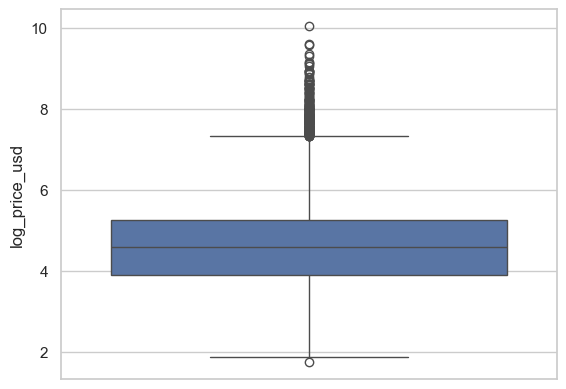

In [25]:
sns.boxplot(y = df['log_price_usd'])

### Matriz de Correlações

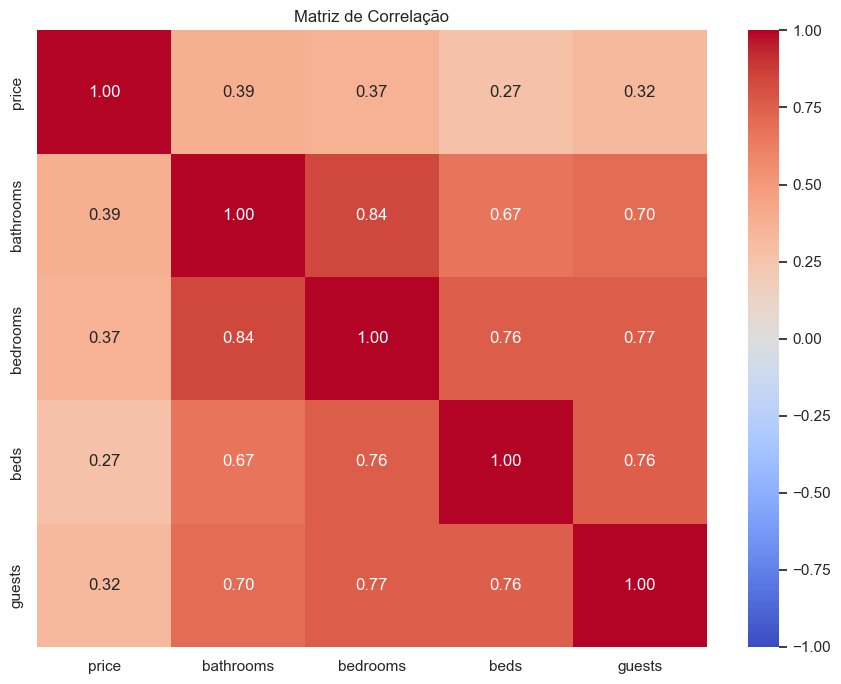

In [26]:


# limpar rating e reviews antes (ainda estão como texto)
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')  # "New" vira NaN
df['reviews_num'] = pd.to_numeric(df['reviews'], errors='coerce')

colunas = ['price', 'bathrooms', 'bedrooms', 'beds', 'guests']

corr = df[colunas].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

#Acho que da pra cortar de toiles até rating_num

### Dispersão de Preço vs Características Quantitativas

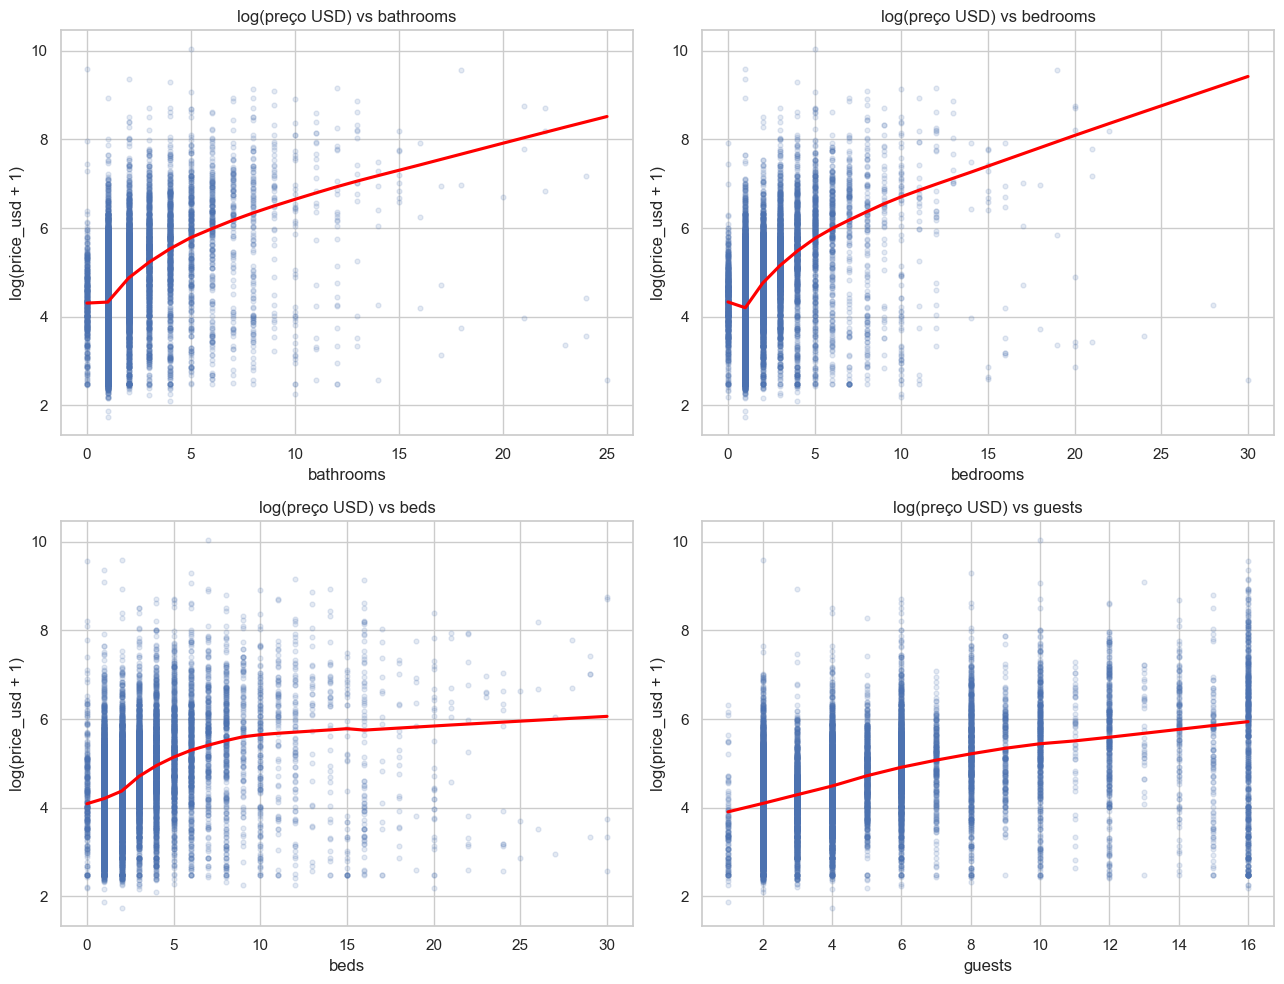

In [27]:
cols = ['bathrooms', 'bedrooms', 'beds', 'guests']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
for i, c in enumerate(cols):
    sns.regplot(x=c, y='log_price_usd', data=df, ax=axes[i],
                scatter_kws={'alpha': 0.15, 's': 12},
                lowess=True, line_kws={'color': 'red'})
    axes[i].set_title(f'log(preço USD) vs {c}')
    axes[i].set_ylabel('log(price_usd + 1)')
plt.tight_layout()
plt.show()

### Quantidade de Studios por Continente --> Será que vale a pena considerar?

In [28]:
# tabela de contagem
tabela_studios = pd.crosstab(df['continente'], df['studios'])
print(tabela_studios)

# tabela de proporção (%) - essa é a que importa pra comparar entre continentes
proporcao_studios = pd.crosstab(df['continente'], df['studios'], normalize='index') * 100
print("\n",proporcao_studios.round(2))

studios             No  Yes
continente                 
América do Norte   556    6
América do Sul      48    1
Europa            4764   80
Oceania             41    0
África             574    5
Ásia              6478  210

 studios               No   Yes
continente                    
América do Norte   98.93  1.07
América do Sul     97.96  2.04
Europa             98.35  1.65
Oceania           100.00  0.00
África             99.14  0.86
Ásia               96.86  3.14


### Boxplot Preço por Studio

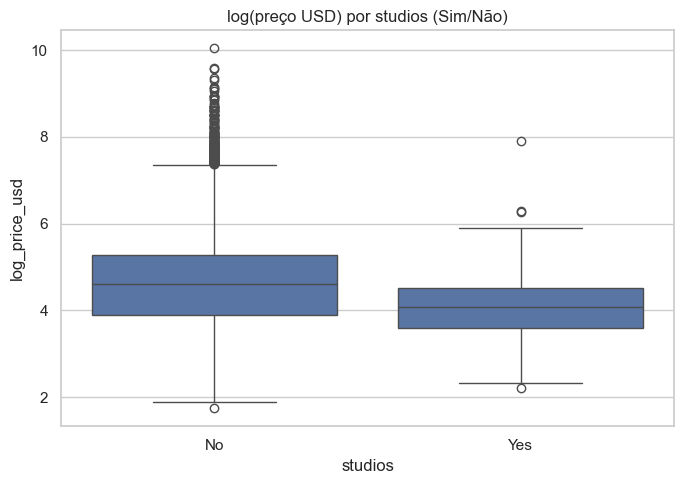

In [29]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='studios', y='log_price_usd', data=df)
plt.title('log(preço USD) por studios (Sim/Não)')
plt.tight_layout()
plt.show()

### Medidas Resumo dos Continentes por Variáveis Quantitativas

In [30]:
colunas_quant = ['bathrooms', 'bedrooms', 'beds', 'guests']

resumo_continente = df.groupby('continente')[colunas_quant].agg(['median', 'mean']).round(2)
resumo_continente

bathrooms       bedrooms         beds       guests      
                    median  mean   median  mean median  mean median  mean
continente                                                               
América do Norte       1.0  1.49      1.0  1.72    2.0  2.94    4.0  4.77
América do Sul         1.0  2.18      2.0  2.29    4.0  4.41    5.0  6.47
Europa                 1.0  1.70      1.0  2.09    2.0  3.33    4.0  5.04
Oceania                1.0  1.22      1.0  1.80    2.0  2.59    4.0  3.98
África                 1.0  2.30      1.0  2.64    2.0  4.33    4.0  5.69
Ásia                   1.0  1.94      1.0  2.05    2.0  2.99    4.0  5.28

### Boxplots Continentes por Variáveis Quantitativas

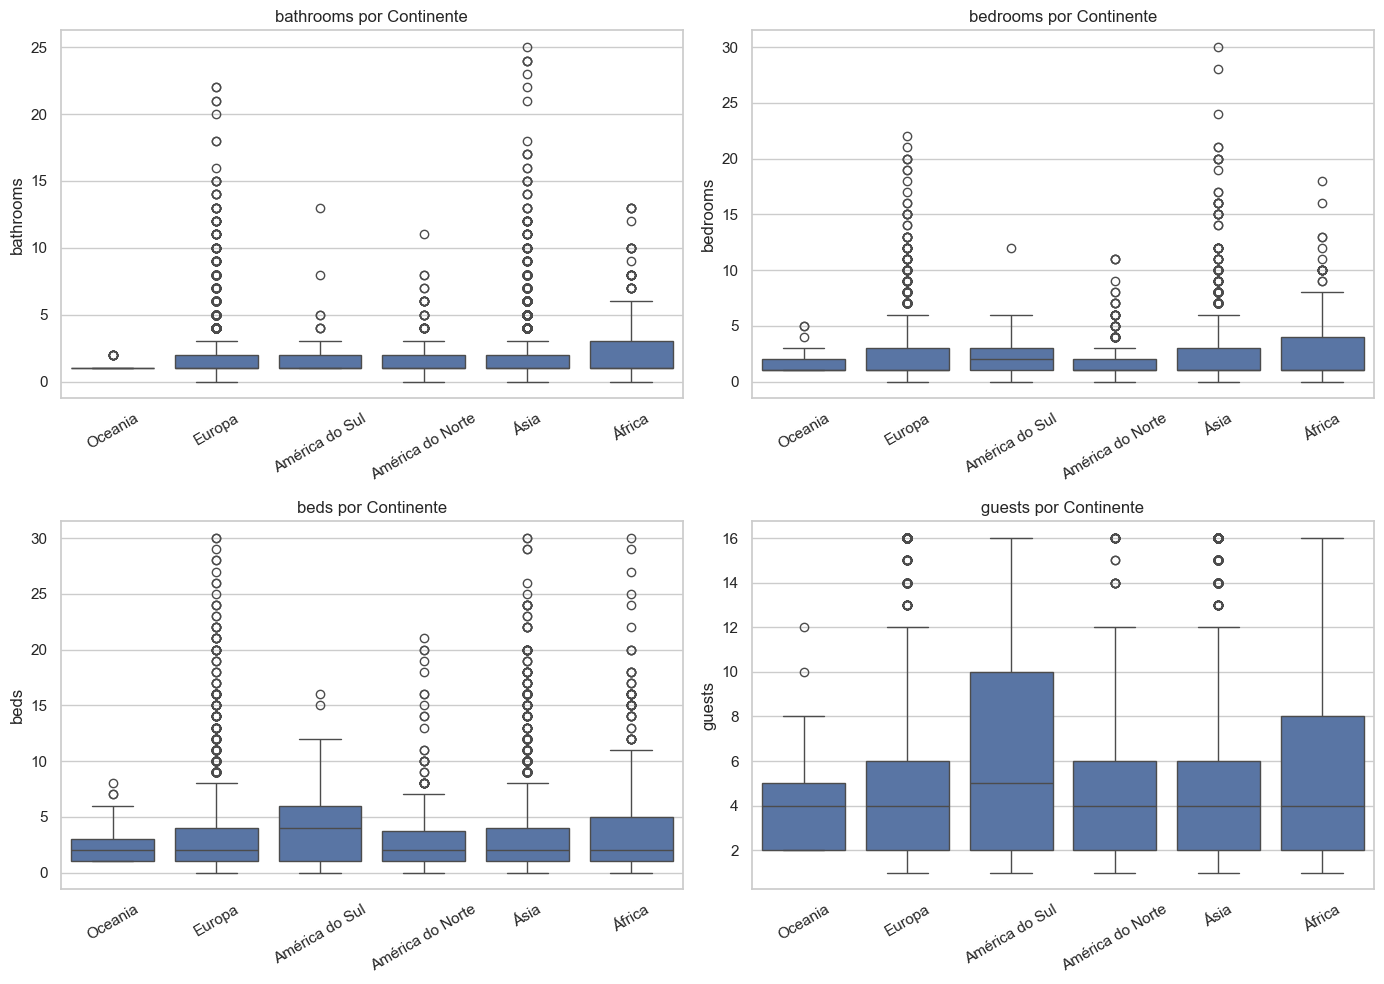

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_quant):
    sns.boxplot(x='continente', y=col, data=df, order=ordem, ax=axes[i])
    axes[i].set_title(f'{col} por Continente')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

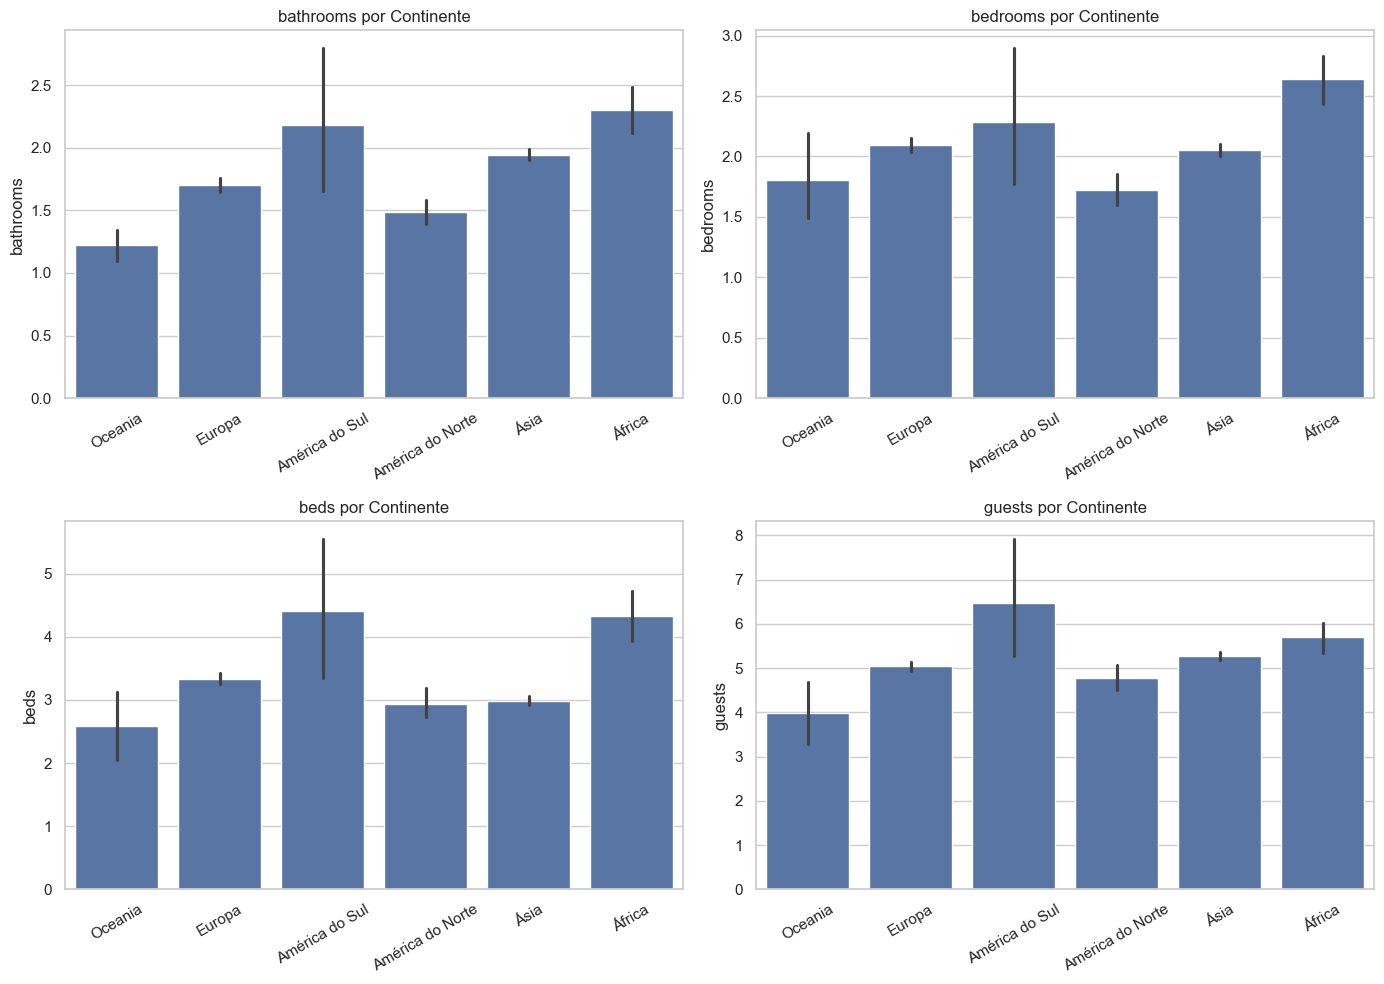

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(colunas_quant):
    sns.barplot(x='continente', y=col, data=df, order=ordem, ax=axes[i])
    axes[i].set_title(f'{col} por Continente')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Verificação da DF com novas variáveis

In [33]:
pd.set_option('display.max_columns', None)
display(df)

,Unnamed: 0,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country,bathrooms,beds,guests,toiles,bedrooms,studios,checkin,checkout,rating_num,reviews_num,price_usd,log_price_usd,continente
0,0,49849504,Perla bungalov,4.71,64,Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: Flexible,Check out: 12:00 pm,Pets ar...",https://a0.muscache.com/im/pictures/a5da5cb7-c...,8078,Turkey,1,1,2,0,2,No,Flexible,12 00 pm,4.71,64.0,97.138047,4.586375,Ásia
1,1,50891766,Authentic Beach Architect Sheltered Villa with...,New,0,Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 4:00 pm - 11:00 pm,Check out: 10:00 ...",https://a0.muscache.com/im/pictures/61b70855-2...,4665,Turkey,2,2,4,0,2,No,4 00 pm - 11 00 pm,10 00 am,NaN,0.0,56.096681,4.044746,Ásia
2,2,50699164,cottages sataplia,4.85,68,Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 1:00 pm,Check out: 12:00 pm,Se...",https://a0.muscache.com/im/pictures/miso/Hosti...,5991,Georgia,1,3,4,0,1,No,After 1 00 pm,12 00 pm,4.85,68.0,72.041847,4.291033,Ásia
3,3,49871422,Sapanca Breathable Bungalow,5.0,13,Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/72e6396e-e...,11339,Turkey,1,2,4,0,1,No,After 2 00 pm,12 00 pm,5.00,13.0,136.351611,4.922544,Ásia
4,4,51245886,Bungalov Ev 2,New,0,Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/73973308-e...,6673,Turkey,1,1,2,0,1,No,After 2 00 pm,12 00 pm,NaN,0.0,80.242905,4.397443,Ásia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12800,12800,44697740,"Brown Dome House No. 3, full of healing",4.94,16,Aidan,161552316.0,"Imhoe-myeon, Jindo, South Jeolla Province, Sou...","4 guests,8 bathrooms","Kitchen,Wifi,Free parking on premises,Private ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠁,C...","Check-in: 3:00 pm - 11:00 pm,Check out: 11:00 ...",https://a0.muscache.com/im/pictures/miso/Hosti...,4288,South Korea,8,0,4,0,0,No,3 00 pm - 11 00 pm,11 00 am,4.94,16.0,51.563252,3.962017,Ásia
12801,12801,29975283,Bubble Hotel Ubud with Bathtub under the Sky,4.67,6,Martha,118954227.0,"Gianyar, Indonesia","2 guests,1 bedroom,1 bed,Toilet with sink","Wifi,Free on-street parking,Air conditioning,G...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 3:00 pm - 10:00 pm,Check out: 12:00 ...",https://a0.muscache.com/im/pictures/5ba944b2-b...,15200,Indonesia,0,1,2,1,1,No,3 00 pm - 10 00 pm,12 00 pm,4.67,6.0,182.780183,5.213740,Ásia
12802,12802,32977697,Paradise Eco Hub,4.67,3,Silas,175214568.0,"Kabale, Uganda","2 guests,1 bedroom,2 beds,1 private bathroom","Wifi,Breakfast,Long-term stays allowed,Unavail...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...",Check-in: After 3:00 pm,https://a0.muscache.com/im/pictures/1f442c84-4...,9103,Uganda,1,2,2,0,1,No,After 3 00 pm,NaN,4.67,3.0,109.463684,4.704687,África
12803,12803,8006146,WisDOME - Mentigi Bay Village - Gilis - Lombok,4.86,7,Cempaka,718423.0,"Gunung Sari, Nusa Tenggara Barat, Indonesia","8 guests,2 bedrooms,4 beds,2.5 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID